## Access Station Lucinda Jetty Daily Wetlabs-Wqm (Parquet)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_daily_wetlabs-wqm data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_wetlabs-wqm.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_daily_wetlabs_wqm"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 41ms
Checked 155 packages in 1ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [3]:
from DataQuery import GetAodn, plot_ts_diagram

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4355: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 6.48 ms, sys: 185 µs, total: 6.67 ms
Wall time: 6.11 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 12.8 ms, sys: 303 µs, total: 13.1 ms
Wall time: 11.6 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


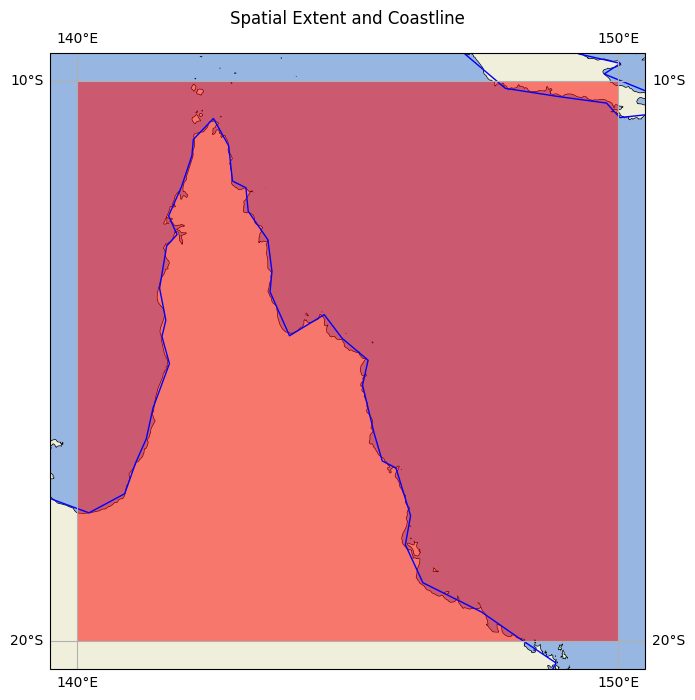

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 1.05 s, sys: 313 ms, total: 1.36 s
Wall time: 3.73 s


(Timestamp('2014-01-09 05:25:00'), Timestamp('2024-08-21 23:15:00'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-05-19 15:34:24,364 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/station_lucinda_jetty_daily_wetlabs_wqm.parquet


{'TIME': {'type': 'timestamp[ns]',
  'axis': 'T',
  'comments': 'This is the start of time bin. ',
  'long_name': 'time',
  'standard_name': 'time',
  'valid_max': 90000.0,
  'valid_min': 0.0},
 'LATITUDE': {'type': 'double',
  'axis': 'Y',
  'long_name': 'latitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'latitude',
  'units': 'degrees_north',
  'valid_max': 90.0,
  'valid_min': -90.0},
 'LONGITUDE': {'type': 'double',
  'axis': 'X',
  'long_name': 'longitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'longitude',
  'units': 'degrees_east',
  'valid_max': 180.0,
  'valid_min': -180.0},
 'NOMINAL_DEPTH': {'type': 'double',
  'axis': 'Z',
  'long_name': 'nominal depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standard_name': 'depth',
  'units': 'metres',
  'valid_max': 12000.0,
  'valid_min': -5.0},
 'CHLF': {'type': 'double',
  'ancillary_variables': 'CHLF_num_obs CHLF_sd CH

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(date_start='2022-12-01', 
                           date_end='2023-03-01',
                           index_time=False)

df.info()

2026-05-19 15:34:43,461 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/station_lucinda_jetty_daily_wetlabs_wqm.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15412 entries, 0 to 15411
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   TIME                    15412 non-null  datetime64[ns]
 1   LATITUDE                15412 non-null  float64       
 2   LONGITUDE               15412 non-null  float64       
 3   NOMINAL_DEPTH           15412 non-null  float64       
 4   CHLF                    15412 non-null  float64       
 5   CHLF_max                15412 non-null  float64       
 6   CHLF_min                15412 non-null  float64       
 7   CHLF_num_obs            15412 non-null  float64       
 8   CHLF_sd                 15412 non-null  float64       
 9   CNDC                    15412 non-null  float64       
 10  CNDC_max                15412 non-null  float64       
 11  CNDC_min                15412 non-null  float64       
 12  CNDC_num_obs            15412 non-null  float6

In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

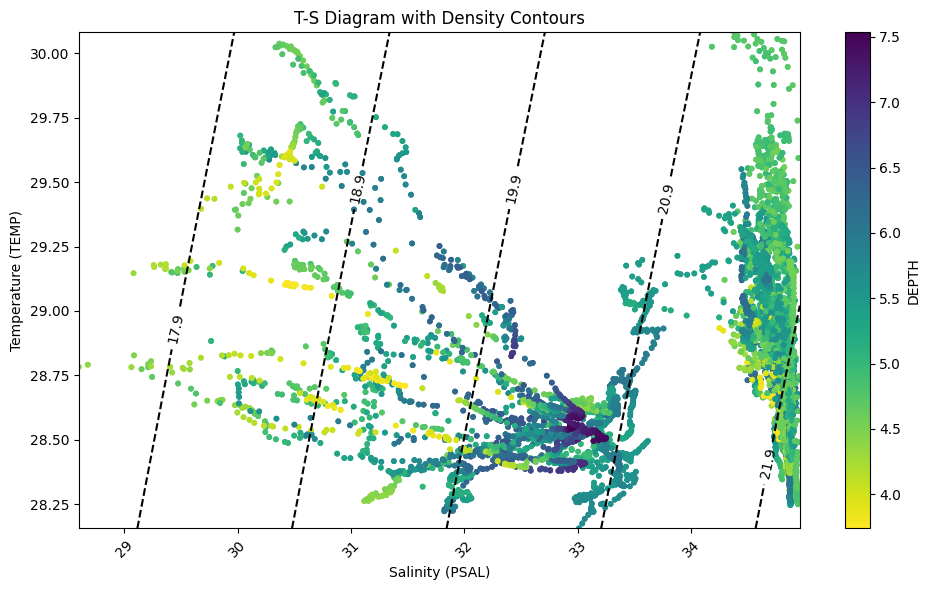

In [13]:
plot_ts_diagram(df, temp_col='TEMP', psal_col='PSAL', z_col='DEPTH')

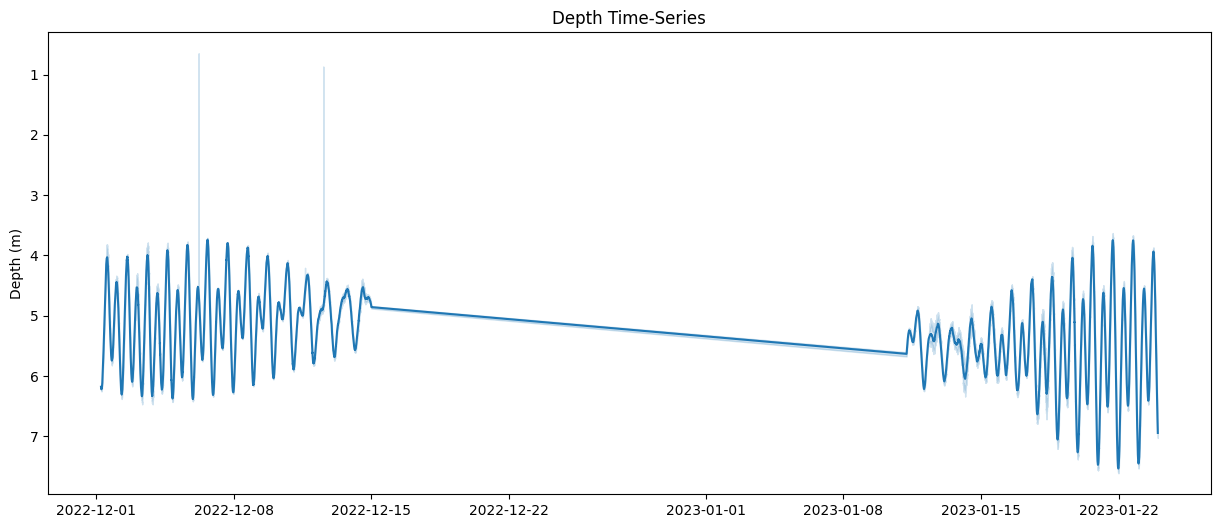

In [14]:
df_time_indexed = df.set_index('TIME')

# 3. Plot using the index directly
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_time_indexed.index, df_time_indexed['DEPTH'], color='tab:blue', label='Mean Depth')
ax.fill_between(df_time_indexed.index, df_time_indexed['DEPTH_min'], df_time_indexed['DEPTH_max'], color='tab:blue', alpha=0.2)

ax.invert_yaxis()
plt.title('Depth Time-Series')
plt.ylabel('Depth (m)')
plt.show()

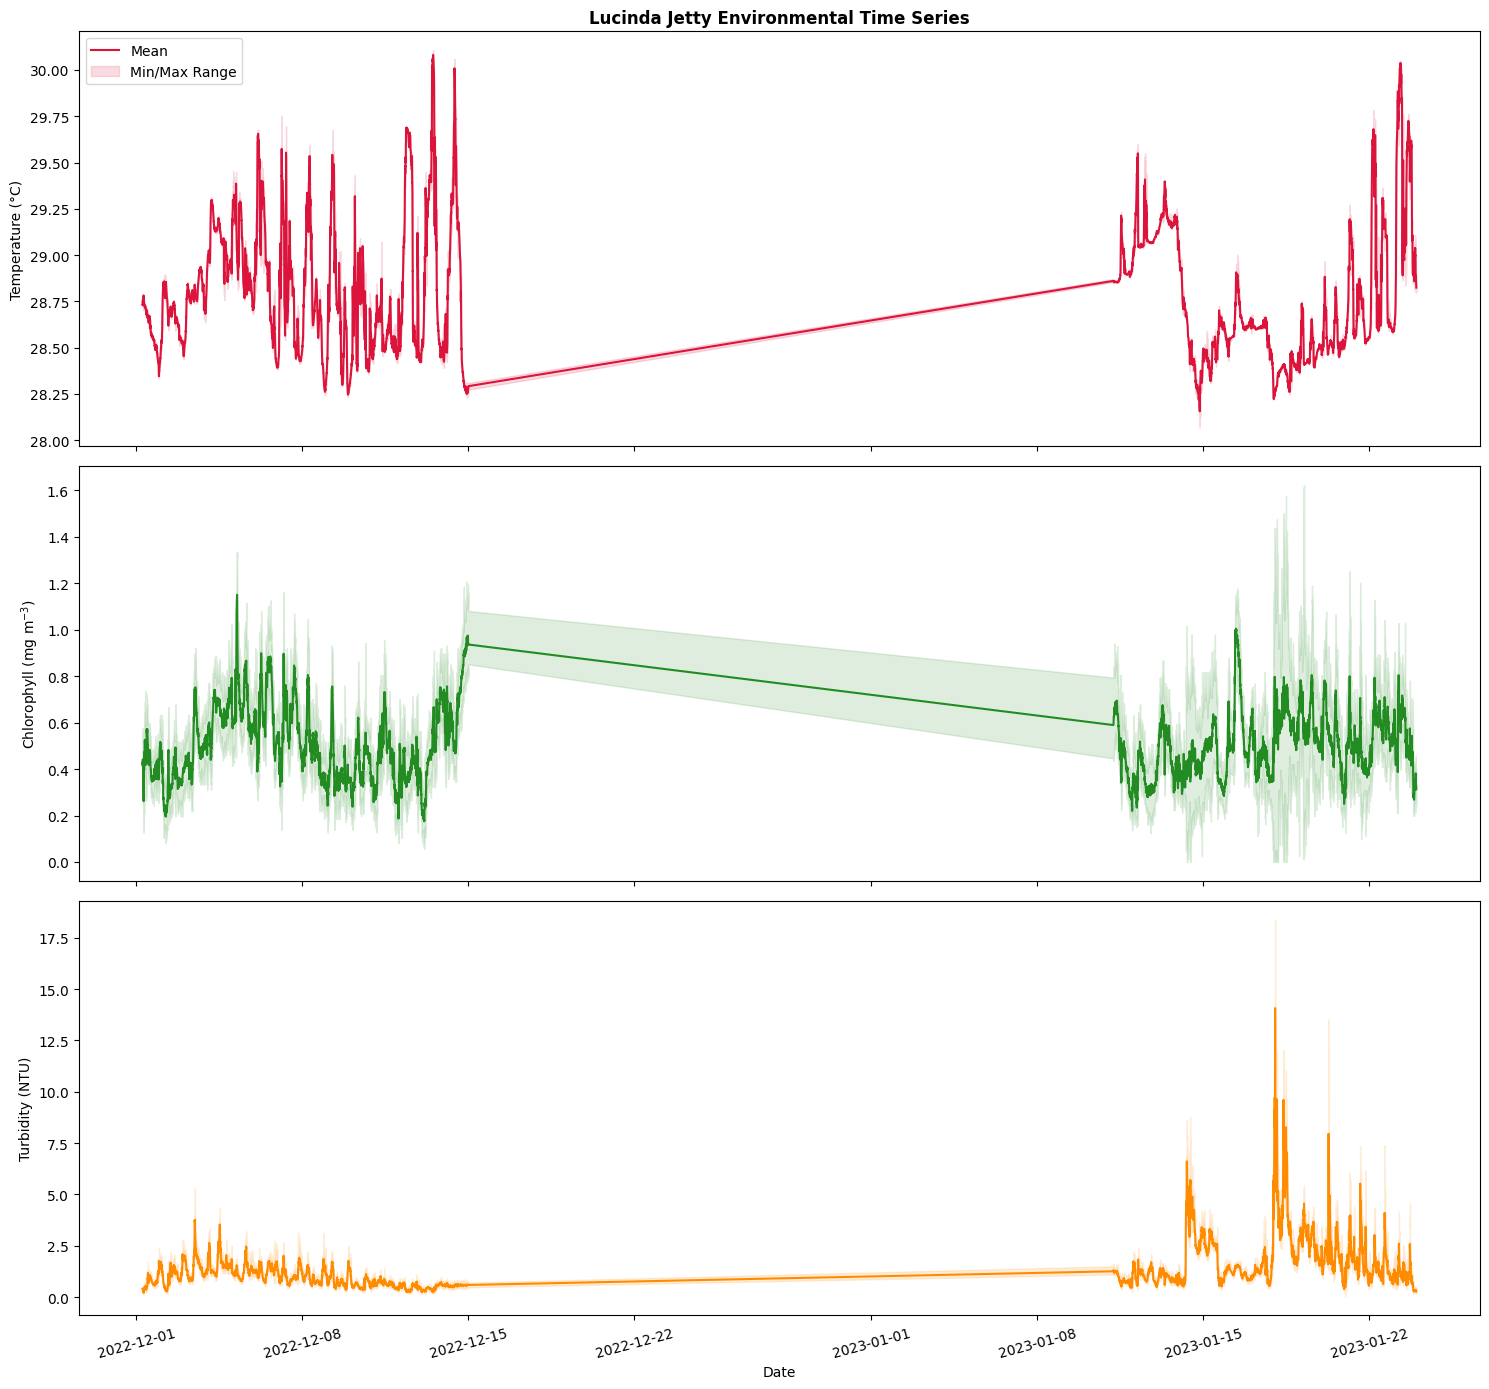

In [15]:
# Multi-panel time series showing environmental variability
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

# Temperature Panel
axes[0].plot(df["TIME"], df["TEMP"], color="crimson", label="Mean")
axes[0].fill_between(
    df["TIME"],
    df["TEMP_min"],
    df["TEMP_max"],
    color="crimson",
    alpha=0.15,
    label="Min/Max Range",
)
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Lucinda Jetty Environmental Time Series", weight="bold")
axes[0].legend(loc="upper left")

# Chlorophyll Panel
axes[1].plot(df["TIME"], df["CHLF"], color="forestgreen", label="Mean")
axes[1].fill_between(
    df["TIME"],
    df["CHLF_min"],
    df["CHLF_max"],
    color="forestgreen",
    alpha=0.15,
)
axes[1].set_ylabel("Chlorophyll (mg m$^{-3}$)")

# Turbidity Panel
axes[2].plot(df["TIME"], df["TURB"], color="darkorange", label="Mean")
axes[2].fill_between(
    df["TIME"],
    df["TURB_min"],
    df["TURB_max"],
    color="darkorange",
    alpha=0.15,
)
axes[2].set_ylabel("Turbidity (NTU)")
axes[2].set_xlabel("Date")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

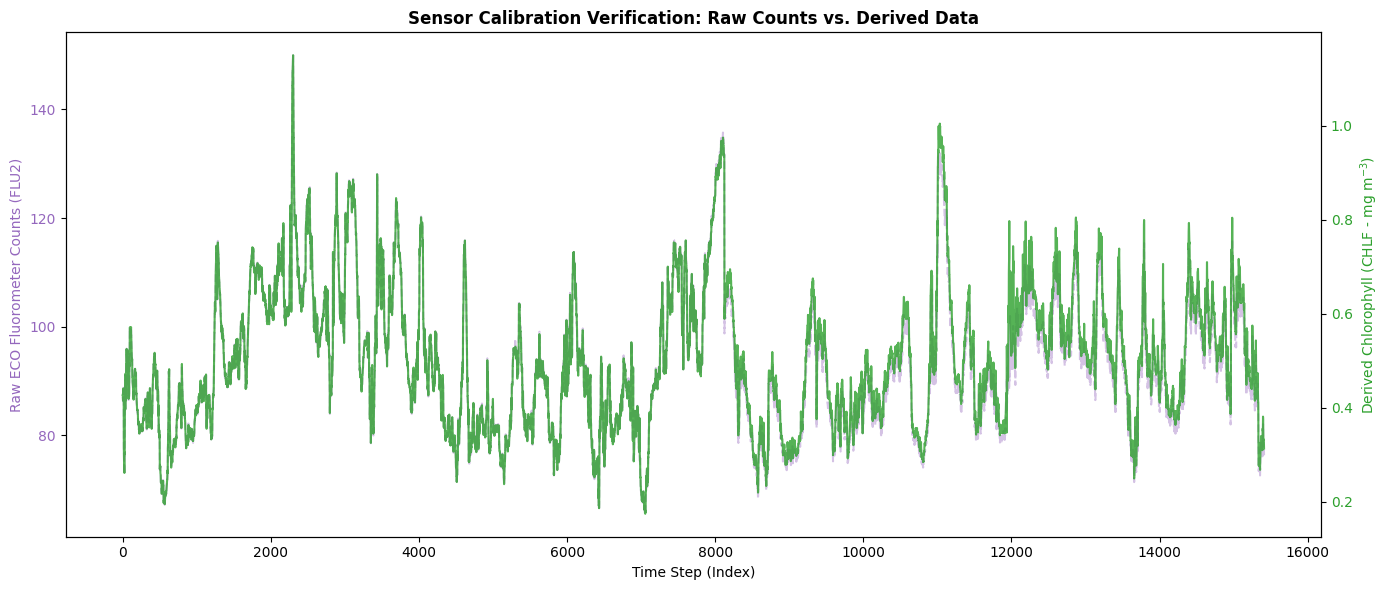

In [16]:
# 3. Validation: Raw Fluorescence Counts vs Calculated Chlorophyll
scale_factor = metadata["FLU2"]["Scale_Factor"]
dark_counts = metadata["FLU2"]["Dark_Counts"]

# Reconstruct using metadata calibration formula
df["CHLF_calculated"] = scale_factor * (
    df["FLU2"] - dark_counts
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot the raw digital counts
color = "tab:purple"
ax1.set_xlabel("Time Step (Index)")
ax1.set_ylabel("Raw ECO Fluorometer Counts (FLU2)", color=color)
ax1.plot(df["FLU2"].values, color=color, alpha=0.4, linestyle="--")
ax1.tick_params(axis="y", labelcolor=color)

# Overlay the final processed Chlorophyll variable to show perfect alignment
ax2 = ax1.twinx()
color = "tab:green"
ax2.set_ylabel("Derived Chlorophyll (CHLF - mg m$^{-3}$)", color=color)
ax2.plot(df["CHLF"].values, color=color, alpha=0.8)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Sensor Calibration Verification: Raw Counts vs. Derived Data",
    weight="bold",
)
fig.tight_layout()
plt.show()


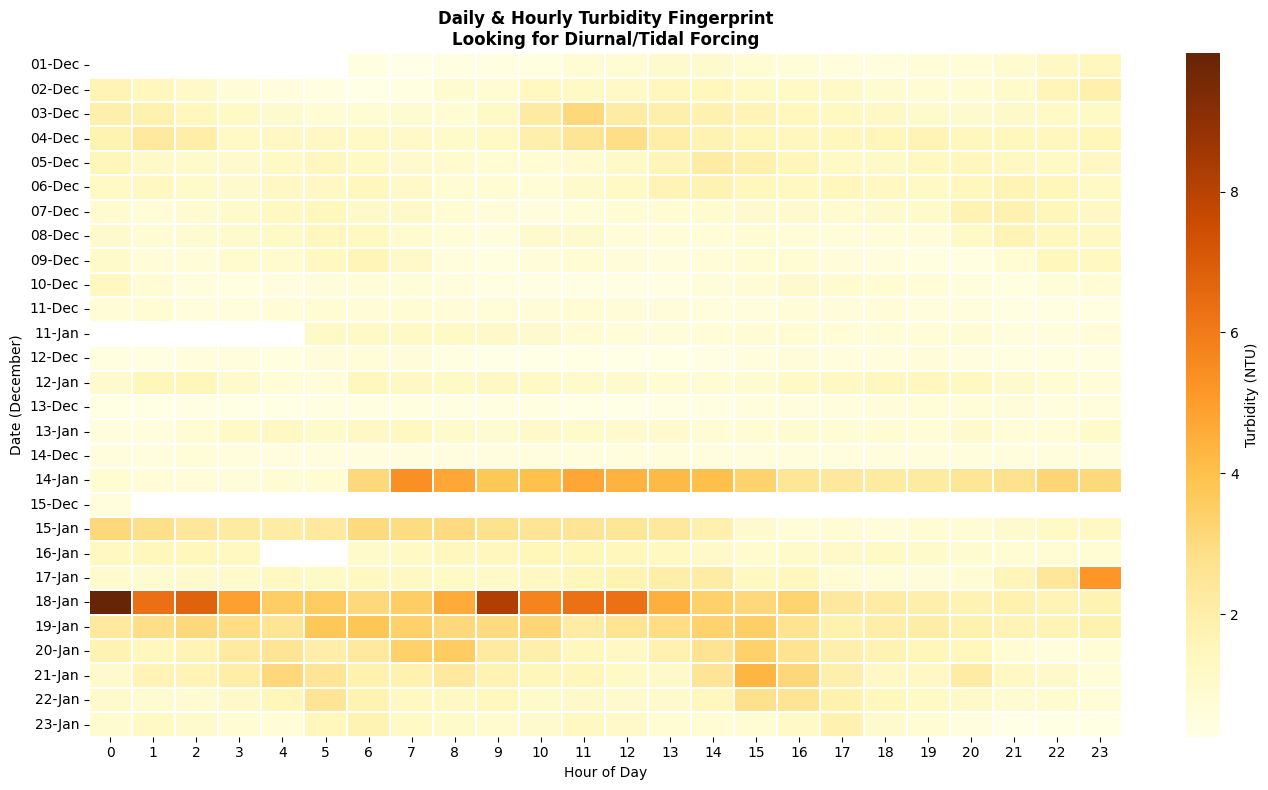

In [17]:
# Hourly Heatmap of Turbidity to observe diurnal patterns
df_heat = df.copy()
df_heat["Hour"] = df_heat["TIME"].dt.hour
df_heat["Day"] = df_heat["TIME"].dt.strftime("%d-%b")

# Pivot to create a Day x Hour grid
pivot_df = df_heat.pivot_table(
    index="Day", columns="Hour", values="TURB", aggfunc="mean"
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_df,
    cmap="YlOrBr",
    cbar_kws={"label": "Turbidity (NTU)"},
    linewidths=0.1,
)
plt.title(
    "Daily & Hourly Turbidity Fingerprint\nLooking for Diurnal/Tidal Forcing",
    weight="bold",
)
plt.xlabel("Hour of Day")
plt.ylabel("Date (December)")
plt.tight_layout()
plt.show()

* Vertical Patterns: Identify consistent diurnal cycles
* Diagonal Patterns: Reveal tidal forcing (because of tidal daily shift)
* Horizontal Patterns: Isolate event-driven spikes (storm ...)